# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Осінна Єлизавета Сергіївна'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-33'      # напр. 'КН-31'
ВАРІАНТ = 8     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Осінна Єлизавета Сергіївна, ШІ-33, варіант 8
ваш потік:                   P>5
ваша пара для графіка 3:     швидкість вітру та густина вітру
ваш агрегат для етапу 4:     максимум
ваше додаткове питання:      Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
# ВАШ КОД
df = pd.read_excel(ФАЙЛ)
df.head(20)

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
5,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >30 = Particles at >30 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)*
Звичайне читання дало такий результат, тому що файл не є однією чистою таблицею. На аркуші Sheet1 знаходиться три різні таблиці, розділені порожніми стовпцями, і кожна з них має свій власний блок текстових заголовків та метаданих. Функція pd.read_excel без додаткових параметрів намагається інтерпретувати весь аркуш як одну таблицю, використовуючи перший рядок як заголовок. Оскільки цей рядок містить лише одне значення (посилання), решта назв стовпців стають Unnamed, а всі подальші текстові рядки (метадані, заголовки підтаблиць) сприймаються як рядки даних.

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
# ВАШ КОД
RAW = pd.read_excel(ФАЙЛ, header=None)
print("Розмір таблиці RAW:", RAW.shape)
RAW.head(30)

Розмір таблиці RAW: (7226, 32)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
# ВАШ КОД
RAW.notna().sum().to_string()

'0        0\n1     7223\n2     7202\n3     7202\n4     7202\n5     7203\n6     7203\n7     7198\n8     7198\n9     7198\n10    7198\n11    7198\n12    7198\n13    7198\n14    7198\n15       0\n16      32\n17      26\n18      26\n19      26\n20       0\n21       0\n22       0\n23       0\n24     601\n25     601\n26     608\n27     602\n28     602\n29     602\n30     602\n31     602'

**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)*
На аркуші є 3 згустки великих чисел: декілька стовпців підряд мають приблизно однакову кількість елементів таблиці. Вони розділені один від одного порожніми стовпцями. Перша таблиця знаходиться у стовпцях 2-15 і містить приблизно по 7200 заповнених рядків. Друга - у стовпцях 17-20 і має 26-32 заповнених рядків. І третя таблиця - у стовпчиках 25-31 має десь по 600 заповнених рядків. Стовпці 16, 21-24 є пустими і розділяють наявні 3 таблиці. Кількість заповнених рядків у стовпцях нібо то однієї таблиці можуть різниитися на декілька значень, адже перші стовпці таблиць містять клітинки з службовими описами такими як джерело даних, дата створення і т д, що не є даними, але теж заповнені.

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:
# ВАШ КОД
for i in range(20):
    for j in range(1, 15):
        value = RAW.iloc[i, j]
        if pd.notna(value):
            print(f"Рядок {i}, стовпець {j}: {value}")

Рядок 0, стовпець 1: ftp://ftp.swpc.noaa.gov/pub/lists/particle/
Рядок 2, стовпець 1: :Data_list: 20170901_Gs_part_5m.txt
Рядок 3, стовпець 1: :Created: 2017 Sep 02 0011 UTC
Рядок 4, стовпець 1: # Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center
Рядок 5, стовпець 1: # Please send comments and suggestions to SWPC.Webmaster@noaa.gov 
Рядок 6, стовпець 1: # 
Рядок 7, стовпець 1: # Label: P > 1 = Particles at >1 Mev
Рядок 8, стовпець 1: # Label: P > 5 = Particles at >5 Mev
Рядок 9, стовпець 1: # Label: P >10 = Particles at >10 Mev
Рядок 10, стовпець 1: # Label: P >30 = Particles at >30 Mev
Рядок 11, стовпець 1: # Label: P >50 = Particles at >50 Mev
Рядок 12, стовпець 1: # Label: P>100 = Particles at >100 Mev
Рядок 13, стовпець 1: # Label: E>0.8 = Electrons at >0.8 Mev
Рядок 14, стовпець 1: # Label: E>2.0 = Electrons at >2.0 Mev
Рядок 15, стовпець 1: # Label: E>4.0 = Electrons at >4.0 Mev
Рядок 16, стовпець 1: # Units: Particles = Protons/cm2-s-sr
Рядок 17, стов

In [8]:
for i in range(30):
    for j in range(16, 20):
        value = RAW.iloc[i, j]
        if pd.notna(value):
            print(f"Рядок {i}, стовпець {j}: {value}")

Рядок 13, стовпець 16: ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt
Рядок 15, стовпець 16: Product: Daily Solar Data         quar_DSD.txt
Рядок 16, стовпець 16: :Issued: 0825 UT 04 Oct 2017
Рядок 17, стовпець 16: #
Рядок 18, стовпець 16: #  Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center
Рядок 19, стовпець 16: #  Please send comments and suggestions to SWPC.Webmaster@noaa.gov
Рядок 23, стовпець 16: Quarterly Daily Solar Data
Рядок 26, стовпець 17: Month
Рядок 26, стовпець 18: Date
Рядок 26, стовпець 19: Radio Flux 10.7
Рядок 27, стовпець 16: 2017
Рядок 27, стовпець 17: 8
Рядок 27, стовпець 18: 28
Рядок 27, стовпець 19: 82
Рядок 28, стовпець 16: 2017
Рядок 28, стовпець 17: 8
Рядок 28, стовпець 18: 29
Рядок 28, стовпець 19: 84
Рядок 29, стовпець 16: 2017
Рядок 29, стовпець 17: 8
Рядок 29, стовпець 18: 30
Рядок 29, стовпець 19: 87


In [9]:
for i in range(10):
    for j in range(24, 31):
        value = RAW.iloc[i, j]
        if pd.notna(value):
            print(f"Рядок {i}, стовпець {j}: {value}")

Рядок 0, стовпець 26: http://umtof.umd.edu/pm/crn/
Рядок 2, стовпець 26: SOHO CELIAS Proton Monitor
Рядок 3, стовпець 26: Solar Wind Parameters for Carrington Rotation (hour averages)
Рядок 4, стовпець 26: Proton speed [km/sec]
Рядок 5, стовпець 26: Proton density [protons per cubic centimeter]
Рядок 7, стовпець 26: Measurement time (Year, Month, Day of Month, Day of Year, Hour, Minute, Second)


**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | ftp://ftp.swpc.noaa.gov/pub/lists/particle/ | протонів/(см²·с·ср) та електронів/(см²·с·ср) |
| B | ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt | sfu = solar flux unit (сонячна одиниця потоку) = 10⁻²² Вт/(м²·Гц) |
| C | http://umtof.umd.edu/pm/crn/ | км/с (швидкість протона) та протонів/см³ (густина протона) |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [10]:
# Скільки рядків у таблиці A
n_A = RAW.iloc[26:, 2].notna().sum()
print("Кількість рядків даних у таблиці A:", n_A)

n_B = RAW.iloc[26:, 16].notna().sum()   # -1, бо в рядку 26 стоїть текст "Radio Flux 10.7"
print("Кількість рядків даних у таблиці B:", n_B)

n_C = RAW.iloc[26:, 26].notna().sum() - 1   # -1, бо в рядку 26 стоїть текст "DENSITY"
print("Кількість рядків даних у таблиці C:", n_C)


A = RAW.iloc[26:26 + n_A, 1:15].copy()
A.columns = [
    'year', 'month', 'day', 'HHMM',
    'julian_day', 'seconds_of_day',
    'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100',
    'E>0.8', 'E>2.0'
]
for col in A.columns:
    A[col] = pd.to_numeric(A[col], errors='coerce')
A = A.reset_index(drop=True)

B = RAW.iloc[27:27 + n_B, 16:20].copy()
B.columns = ['year', 'month', 'day', 'F10.7']
for col in B.columns:
    B[col] = pd.to_numeric(B[col], errors='coerce')
B = B.reset_index(drop=True)

C = RAW.iloc[27:27 + n_C, 26:32].copy()
C.columns = ['year', 'month', 'day', 'hour', 'speed', 'density']
for col in C.columns:
    C[col] = pd.to_numeric(C[col], errors='coerce')
C = C.reset_index(drop=True)

print("A:", A.shape)
print("B:", B.shape)
print("C:", C.shape)
print("\nA.head():")
print(A.head())
print("\nB.head():")
print(B.head())
print("\nC.head():")
print(C.head())

Кількість рядків даних у таблиці A: 7200
Кількість рядків даних у таблиці B: 25
Кількість рядків даних у таблиці C: 601
A: (7200, 14)
B: (25, 4)
C: (601, 6)

A.head():
   year  month  day  HHMM  julian_day  seconds_of_day    P>1    P>5   P>10    P>30    P>50   P>100    E>0.8   E>2.0
0  2017      8   28     0       57993               0  12.00  0.260  0.180  0.1140  0.1040  0.0793  23600.0  1180.0
1  2017      8   28     5       57993             300  19.40  0.690  0.314  0.1120  0.0612  0.0251  23100.0  1160.0
2  2017      8   28    10       57993             600   8.48  0.168  0.130  0.0717  0.0614  0.0304  22200.0  1090.0
3  2017      8   28    15       57993             900  15.40  0.566  0.198  0.0926  0.0568  0.0251  20400.0   997.0
4  2017      8   28    20       57993            1200   6.41  0.156  0.118  0.0597  0.0494  0.0251  18500.0   875.0

B.head():
   year  month  day  F10.7
0  2017      8   28     82
1  2017      8   29     84
2  2017      8   30     87
3  2017      8   

### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [11]:
A['year'] = A['year'].astype(int)
A['month'] = A['month'].astype(int)
A['day'] = A['day'].astype(int)
A['HHMM'] = A['HHMM'].astype(int)

HHMM = A['HHMM'].astype(str).str.zfill(4)

A['ts'] = pd.to_datetime(
    A['year'].astype(str) + '-' +
    A['month'].astype(str).str.zfill(2) + '-' +
    A['day'].astype(str).str.zfill(2) + ' ' +
    HHMM.str[:2] + ':' + HHMM.str[2:] + ':00',
    format='%Y-%m-%d %H:%M:%S',
    errors='coerce'
)

B['year'] = B['year'].astype(int)
B['month'] = B['month'].astype(int)
B['day'] = B['day'].astype(int)

B['ts'] = pd.to_datetime(
    B['year'].astype(str) + '-' +
    B['month'].astype(str).str.zfill(2) + '-' +
    B['day'].astype(str).str.zfill(2),
    format='%Y-%m-%d',
    errors='coerce'
)

# У таблиці C рік двозначний (17) — додаємо 2000. Час — окремий стовпець 'hour'.
C['year'] = C['year'].astype(int) + 2000
C['month'] = C['month'].astype(int)
C['day'] = C['day'].astype(int)
C['hour'] = C['hour'].astype(int)

C['ts'] = pd.to_datetime(
    C['year'].astype(str) + '-' +
    C['month'].astype(str).str.zfill(2) + '-' +
    C['day'].astype(str).str.zfill(2) + ' ' +
    C['hour'].astype(str).str.zfill(2) + ':00:00',
    format='%Y-%m-%d %H:%M:%S',
    errors='coerce'
)

for name, tbl in [('A', A), ('B', B), ('C', C)]:
    print(f"--- {name} ---")
    print(tbl['ts'].head(5).to_string(index=False))
    print(f"  dtype: {tbl['ts'].dtype}")
    print(f"  min:   {tbl['ts'].min()}")
    print(f"  max:   {tbl['ts'].max()}")
    print(f"  NaT:   {tbl['ts'].isna().sum()}")
    print()

--- A ---
2017-08-28 00:00:00
2017-08-28 00:05:00
2017-08-28 00:10:00
2017-08-28 00:15:00
2017-08-28 00:20:00
  dtype: datetime64[us]
  min:   2017-08-28 00:00:00
  max:   2017-09-21 23:55:00
  NaT:   0

--- B ---
2017-08-28
2017-08-29
2017-08-30
2017-08-31
2017-09-01
  dtype: datetime64[us]
  min:   2017-08-28 00:00:00
  max:   2017-09-21 00:00:00
  NaT:   0

--- C ---
2017-08-28 00:00:00
2017-08-28 01:00:00
2017-08-28 02:00:00
2017-08-28 03:00:00
2017-08-28 04:00:00
  dtype: datetime64[us]
  min:   2017-08-28 00:00:00
  max:   2017-09-22 00:00:00
  NaT:   0



**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [12]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [13]:
for name, tbl in [('A', A), ('B', B), ('C', C)]:
    print(f"\n===== {name} | shape={tbl.shape} | "
          f"дублікатів={tbl.duplicated().sum()} | "
          f"пропусків всього={tbl.isna().sum().sum()} =====")
    print("Типи:", tbl.dtypes.value_counts().to_dict())


===== A | shape=(7200, 15) | дублікатів=0 | пропусків всього=24 =====
Типи: {dtype('float64'): 8, dtype('int64'): 6, dtype('<M8[us]'): 1}

===== B | shape=(25, 5) | дублікатів=0 | пропусків всього=0 =====
Типи: {dtype('int64'): 4, dtype('<M8[us]'): 1}

===== C | shape=(601, 7) | дублікатів=0 | пропусків всього=0 =====
Типи: {dtype('int64'): 5, dtype('float64'): 1, dtype('<M8[us]'): 1}


In [14]:
for name, tbl in [('A', A), ('B', B), ('C', C)]:
    print("Пропуски по стовпцях:")
    print(tbl.isna().sum().to_string())

Пропуски по стовпцях:
year              0
month             0
day               0
HHMM              0
julian_day        0
seconds_of_day    0
P>1               3
P>5               3
P>10              3
P>30              3
P>50              3
P>100             3
E>0.8             3
E>2.0             3
ts                0
Пропуски по стовпцях:
year     0
month    0
day      0
F10.7    0
ts       0
Пропуски по стовпцях:
year       0
month      0
day        0
hour       0
speed      0
density    0
ts         0


In [15]:
A.describe()

,year,month,day,HHMM,julian_day,seconds_of_day,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,NaN


In [16]:
B.describe()

,year,month,day,F10.7,ts
count,25.0,25.000000,25.000000,25.000000,25
mean,2017.0,8.840000,13.960000,92.680000,2017-09-09 00:00:00
min,2017.0,8.000000,1.000000,71.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,74.000000,2017-09-03 00:00:00
50%,2017.0,9.000000,13.000000,84.000000,2017-09-09 00:00:00
75%,2017.0,9.000000,19.000000,107.000000,2017-09-15 00:00:00
max,2017.0,9.000000,31.000000,140.000000,2017-09-21 00:00:00
std,0.0,0.374166,8.955817,22.206831,NaN


In [17]:
C.describe()

,year,month,day,hour,speed,density,ts
count,601.0,601.000000,601.000000,601.000000,601.000000,601.000000,601
mean,2017.0,8.840266,13.973378,11.480865,506.547421,2.907654,2017-09-09 12:00:00
min,2017.0,8.000000,1.000000,0.000000,-1.000000,-1.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,5.000000,447.000000,1.800000,2017-09-03 06:00:00
50%,2017.0,9.000000,13.000000,11.000000,517.000000,2.400000,2017-09-09 12:00:00
75%,2017.0,9.000000,19.000000,17.000000,584.000000,3.400000,2017-09-15 18:00:00
max,2017.0,9.000000,31.000000,23.000000,806.000000,31.700000,2017-09-22 00:00:00
std,0.0,0.366664,8.781000,6.938063,125.073291,2.637873,NaN


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [18]:
neg_speed = C[C['speed'] < 0]
neg_density = C[C['density'] < 0]

print(f"\nКількість від'ємних значень у speed:   {len(neg_speed)}")
print(f"Кількість від'ємних значень у density: {len(neg_density)}")

print("\nПриклади від'ємних рядків:")
print(C[(C['speed'] < 0) | (C['density'] < 0)][['ts', 'speed', 'density']].head(10))




Кількість від'ємних значень у speed:   8
Кількість від'ємних значень у density: 8

Приклади від'ємних рядків:
                     ts  speed  density
175 2017-09-04 07:00:00     -1     -1.0
176 2017-09-04 08:00:00     -1     -1.0
177 2017-09-04 09:00:00     -1     -1.0
178 2017-09-04 10:00:00     -1     -1.0
179 2017-09-04 11:00:00     -1     -1.0
180 2017-09-04 12:00:00     -1     -1.0
181 2017-09-04 13:00:00     -1     -1.0
182 2017-09-04 14:00:00     -1     -1.0


In [19]:
# 3. Запам'ятати статистики "ДО"
before = C[['speed', 'density']].agg(['mean', 'min'])
print("\nСтатистики 'ДО' заміни:")
print(before)

# 4. Замінити від'ємні значення на NaN
C['speed'] = C['speed'].where(C['speed'] >= 0, np.nan)
C['density'] = C['density'].where(C['density'] >= 0, np.nan)

# 5. Показати статистики "ПІСЛЯ"
after = C[['speed', 'density']].agg(['mean', 'min'])
print("\nСтатистики 'ПІСЛЯ' заміни:")
print(after)


Статистики 'ДО' заміни:
           speed   density
mean  506.547421  2.907654
min    -1.000000 -1.000000

Статистики 'ПІСЛЯ' заміни:
           speed   density
mean  513.394604  2.960371
min   277.000000  0.100000


**Відповідь 3.2:** *(що це за значення, скільки їх, як вони спотворювали середнє)*
У стовпцях speed (швидкість вітру) та density (густина вітру) зустрічаються значення -1, і це не справжні вимірювання, а службовий код, яким у файлі позначили пропущені дані (про це прямо сказано в рядку # Missing data: -1.00e+05). Таких значень по 8 штук у кожному зі стовпців, і всі вони йдуть підряд одним суцільним блоком — з 07:00 до 14:00 4 вересня 2017 року, тобто це не випадкові «викиди», а один проміжок, коли прилад не передавав дані.

Якби залишити -1 як є, програма сприймала б його за реальне число, і воно б псувало статистику: середнє штучно занижувалося б (швидкість показувалася як 506.55 замість реальних 513.39, а густина — 2.91 замість 2.96), а мінімум взагалі ставав би безглуздим (-1.0 км/с і -1.0 частинок/см³, хоча фізично ці величини не можуть бути від'ємними; насправді мінімуми — 277.0 км/с і 0.1 частинок/см³). Після заміни всіх -1 на NaN (тобто «пропуск») статистики стали коректними.

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [20]:
# ВАШ КОД
A.describe()


,year,month,day,HHMM,julian_day,seconds_of_day,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,NaN


**Відповідь 3.3:** *(які це стовпці та чому середнє для них не має сенсу)*
Середнє та стандартне відхилення не мають сенсу для стовпців year, month, day, HHMM, julian_day і seconds_of_day. Ці стовпці показують час, а не вимірюють якусь величину: це рік, місяць, день, години й хвилини, номер дня в році та секунди від початку доби. Просто вони записані числами, тому pandas автоматично рахує для них статистики, але ці числа нічого не вимірюють, і шукати для них середнє безглуздо. Ці стовпці потрібні лише для того, щоб зібрати з них одну дату (datetime) й далі працювати з нею як з часом, а не як з числом для статистики.

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [21]:
# робимо ts індексом
A_idx = A.set_index('ts')

A_hourly = A_idx.resample('h').agg({
    'P>1':   ['mean', 'max'],
    'P>5':   ['mean', 'max'],
    'P>10':  ['mean', 'max'],
    'P>30':  ['mean', 'max'],
    'P>50':  ['mean', 'max'],
    'P>100': ['mean', 'max'],
    'E>0.8': ['mean', 'max'],
    'E>2.0': ['mean', 'max'],
})

A_hourly.columns = ['_'.join(col).strip() for col in A_hourly.columns.values]

A_hourly = A_hourly.reset_index()

print("Розмір A_hourly:", A_hourly.shape)
print(A_hourly.head())

Розмір A_hourly: (600, 17)
                   ts  P>1_mean  P>1_max  P>5_mean  P>5_max  P>10_mean  P>10_max  P>30_mean  P>30_max  P>50_mean  P>50_max  P>100_mean  P>100_max    E>0.8_mean  E>0.8_max   E>2.0_mean  E>2.0_max
0 2017-08-28 00:00:00  9.778333    19.40  0.324917    0.690   0.192917     0.314   0.098850    0.2240   0.077583    0.1780    0.040692     0.0793  20941.666667    23600.0  1011.583333     1180.0
1 2017-08-28 01:00:00  7.994167    13.60  0.291667    0.512   0.156583     0.259   0.072583    0.0919   0.058700    0.0798    0.029950     0.0471  18091.666667    20600.0   713.000000      907.0
2 2017-08-28 02:00:00  6.099167    10.80  0.283000    0.479   0.177667     0.321   0.084450    0.1210   0.069642    0.1110    0.035025     0.0595  14108.333333    15000.0   380.833333      475.0
3 2017-08-28 03:00:00  4.752500     7.76  0.236833    0.329   0.166333     0.244   0.087658    0.1800   0.068092    0.1390    0.035517     0.0818  12766.666667    13100.0   267.916667      284.

### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

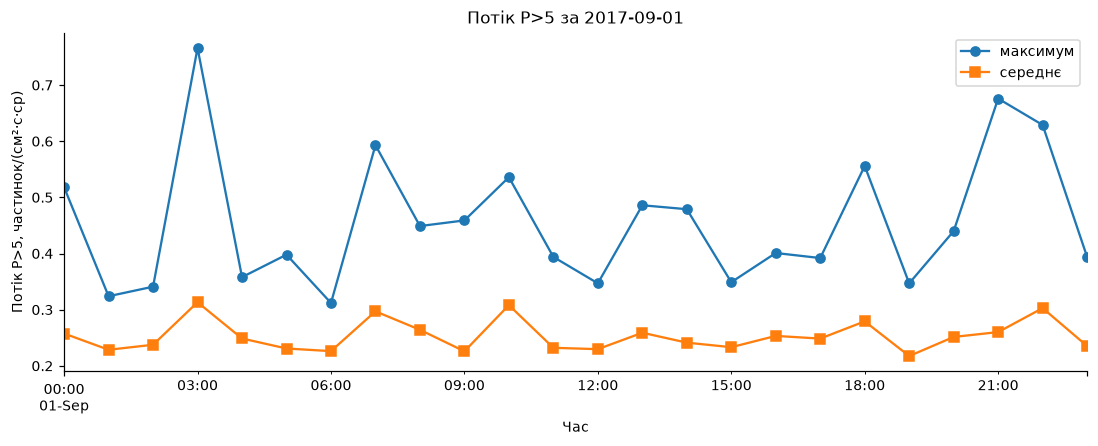

In [22]:
day_data = A[(A['ts'] >= '2017-09-01') & (A['ts'] < '2017-09-02')]

day_data = day_data.set_index('ts')

fig, ax = plt.subplots(figsize=(12, 4))
day_data['P>5'].resample('h').max().plot(ax=ax, label='максимум', marker='o')
day_data['P>5'].resample('h').mean().plot(ax=ax, label='середнє', marker='s')

ax.set_title('Потік P>5 за 2017-09-01')
ax.set_xlabel('Час')
ax.set_ylabel('Потік P>5, частинок/(см²·с·ср)')
ax.legend()
plt.show()

**Відповідь 4.2:** *(чим відрізняються криві та коли це важливо)* 
На цьому графіку синя лінія (максимум) завжди лежить вище за оранжеву (середнє) і жодного разу не опускається нижче. Але різниця між ними не стала: у "спокійні" години (2:00, 5:00, 12:00, 22:00) обидві лінії майже зливаються, а в години зі сплесками (3:00, 7:00, 11:00, 21:00) максимум різко підскакує вгору, а середнє залишається помірним. Отже, максимум добре ловить короткочасні піки, а середнє показує загальний рівень за годину — і чим нерівномірніший потік, тим більше вони розходяться.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [23]:
B_merge = B[['ts', 'F10.7']].copy()
B_merge['date'] = B_merge['ts'].dt.date

C_merge = C[['ts', 'speed', 'density']].copy()
C_merge.set_index('ts', inplace=True)

M_inner = pd.merge(A_hourly, C_merge, on='ts', how='inner')
M_inner['date'] = M_inner['ts'].dt.date
M_inner = pd.merge(M_inner, B_merge[['date', 'F10.7']], on='date', how='inner')
M_inner.drop(columns=['date'], inplace=True)

M_outer = pd.merge(A_hourly, C_merge, on='ts', how='outer')
M_outer['date'] = M_outer['ts'].dt.date
M_outer = pd.merge(M_outer, B_merge[['date', 'F10.7']], on='date', how='left')
M_outer.drop(columns=['date'], inplace=True)

print("inner:", M_inner.shape)
print("outer:", M_outer.shape)

# Скільки годин ми втрачаємо, якщо беремо inner
print("\nРізниця в рядках:", M_outer.shape[0] - M_inner.shape[0])

set_outer = set(M_outer['ts'])
set_inner = set(M_inner['ts'])
lost = sorted(set_outer - set_inner)
print(f"\nГодини, які є в outer, але зникли б у inner ({len(lost)} шт.):")
for t in lost[:10]:
    print("  ", t)

M = M_outer

rows_with_nan = M[M.isnull().any(axis=1)]
print(f"\nРядків із хоча б одним пропуском: {len(rows_with_nan)} з {len(M)}")
print(rows_with_nan)

inner: (600, 20)
outer: (601, 20)

Різниця в рядках: 1

Години, які є в outer, але зникли б у inner (1 шт.):
   2017-09-22 00:00:00

Рядків із хоча б одним пропуском: 9 з 601
                     ts  P>1_mean  P>1_max  P>5_mean  P>5_max  P>10_mean  P>10_max  P>30_mean  P>30_max  P>50_mean  P>50_max  P>100_mean  P>100_max    E>0.8_mean  E>0.8_max   E>2.0_mean  E>2.0_max  \
175 2017-09-04 07:00:00  6.465833    10.10  0.262083    0.593   0.171500     0.294   0.085483     0.145   0.068558     0.134    0.031717     0.0523  90600.000000   100000.0  7410.833333     8950.0   
176 2017-09-04 08:00:00  4.010833     5.08  0.256000    0.432   0.195833     0.336   0.086625     0.145   0.070033     0.134    0.036492     0.0546  73483.333333    79300.0  5048.333333     5850.0   
177 2017-09-04 09:00:00  3.268333     4.42  0.303417    0.518   0.220333     0.302   0.105925     0.162   0.081975     0.134    0.046483     0.0765  60475.000000    68500.0  3715.833333     4480.0   
178 2017-09-04 10:00:00  

In [24]:
print(M.head())

                   ts  P>1_mean  P>1_max  P>5_mean  P>5_max  P>10_mean  P>10_max  P>30_mean  P>30_max  P>50_mean  P>50_max  P>100_mean  P>100_max    E>0.8_mean  E>0.8_max   E>2.0_mean  E>2.0_max  \
0 2017-08-28 00:00:00  9.778333    19.40  0.324917    0.690   0.192917     0.314   0.098850    0.2240   0.077583    0.1780    0.040692     0.0793  20941.666667    23600.0  1011.583333     1180.0   
1 2017-08-28 01:00:00  7.994167    13.60  0.291667    0.512   0.156583     0.259   0.072583    0.0919   0.058700    0.0798    0.029950     0.0471  18091.666667    20600.0   713.000000      907.0   
2 2017-08-28 02:00:00  6.099167    10.80  0.283000    0.479   0.177667     0.321   0.084450    0.1210   0.069642    0.1110    0.035025     0.0595  14108.333333    15000.0   380.833333      475.0   
3 2017-08-28 03:00:00  4.752500     7.76  0.236833    0.329   0.166333     0.244   0.087658    0.1800   0.068092    0.1390    0.035517     0.0818  12766.666667    13100.0   267.916667      284.0   
4 2017-08-

**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)*
Обрано тип об'єднання how='outer', який дає 601 рядок — на одну годину більше, ніж how='inner' (600 рядків). Ця різниця виникає через те, що таблиці мають різні часові діапазони: A закінчується 21.09 23:55, B — 20.09, а C — 22.09 00:00. Варіант inner залишив би лише ті години, які є одночасно в усіх трьох таблицях, і викинув би годину 2017-09-22 00:00:00, яка присутня лише в C. Варіант outer зберігає всі унікальні мітки часу з усіх таблиць, а відсутні значення заповнює NaN, що дозволяє працювати з повним періодом спостережень без втрати крайніх точок.

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [25]:
# ВАШ КОД
def categorize_group(max_p10):
    if max_p10 < 10:
        return 'тиха'
    elif max_p10 < 1000:
        return 'активна'
    else:
        return 'дуже активна'

M['група'] = M['P>10_max'].apply(categorize_group)

print(M['група'].value_counts())

група
тиха            411
активна         171
дуже активна     19
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [26]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 601 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

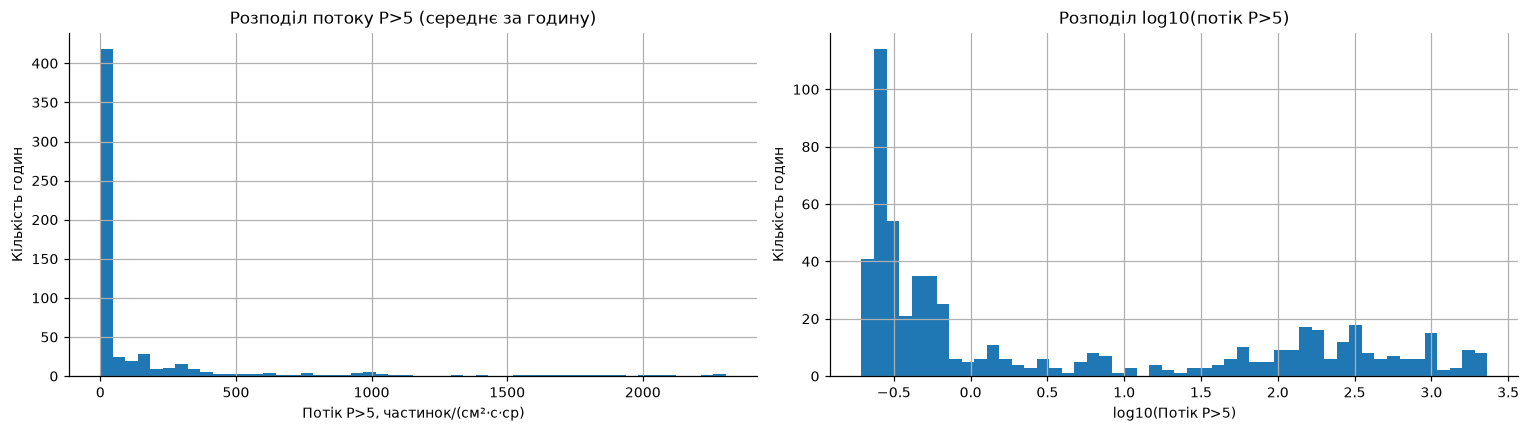

Середнє: 156.59
Медіана: 0.60


In [27]:
# ВАШ КОД
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

M['P>5_mean'].hist(bins=50, ax=ax[0])
ax[0].set_title('Розподіл потоку P>5 (середнє за годину)')
ax[0].set_xlabel('Потік P>5, частинок/(см²·с·ср)')
ax[0].set_ylabel('Кількість годин')

np.log10(M['P>5_mean'].replace(0, np.nan)).hist(bins=50, ax=ax[1])
ax[1].set_title('Розподіл log10(потік P>5)')
ax[1].set_xlabel('log10(Потік P>5)')
ax[1].set_ylabel('Кількість годин')

plt.tight_layout()
plt.show()

print(f"Середнє: {M['P>5_mean'].mean():.2f}")
print(f"Медіана: {M['P>5_mean'].median():.2f}")

**Висновок:** Розподіл потоку P>5 дуже нерівний: медіана 0.60, а середнє 156.59 — різниця у 260 разів. Це тому, що більшість годин мають дуже малий потік (близько 0.6), але кілька годин зі спалахами дають величезні значення. Саме ці поодинокі спалахи так сильно піднімають середнє вгору.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

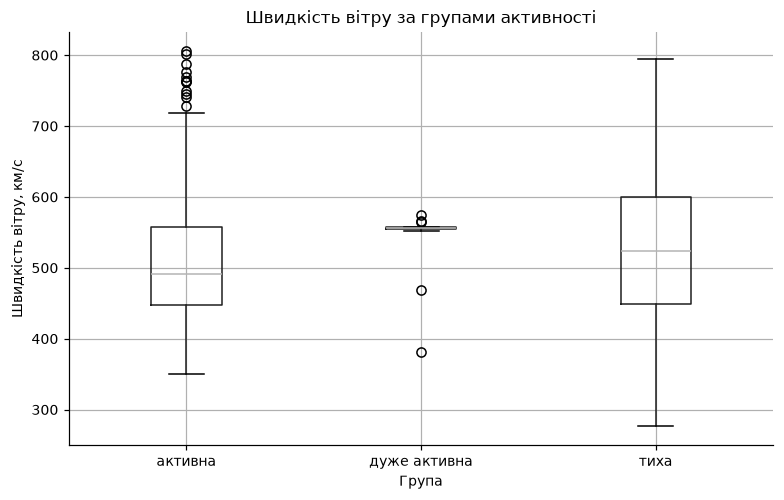

In [28]:
# ВАШ КОД
fig, ax = plt.subplots(figsize=(8, 5))
M.boxplot(column='speed', by='група', ax=ax)
ax.set_title('Швидкість вітру за групами активності')
ax.set_xlabel('Група')
ax.set_ylabel('Швидкість вітру, км/с')
plt.suptitle('')
plt.show()

**Висновок:** Так, швидкість сонячного вітру дещо відрізняється між групами годин, але ця відмінність не є однаково вираженою. Найбільша різниця спостерігається між «активною» та «дуже активною» групами: медіана зростає приблизно від 495 до 555 км/с. Між «тихою» та «активною» групами різниця невелика — 530 та 495 км/с відповідно. Отже, певна залежність є, але швидкість вітру не є визначальним фактором рівня потоку протонів.

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

Кореляція: -0.039


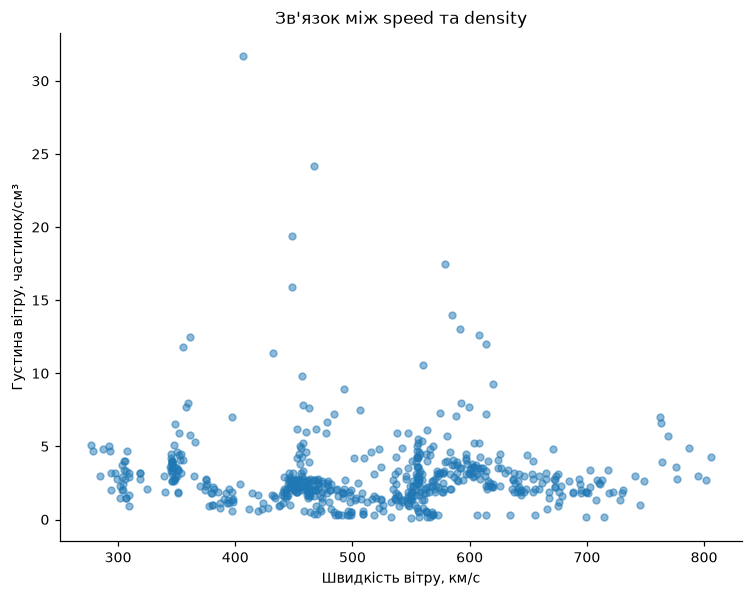

In [29]:
x_col = 'speed'
y_col = 'density'

fig, ax = plt.subplots(figsize=(8, 6))
M.plot.scatter(x=x_col, y=y_col, ax=ax, alpha=0.5)
ax.set_title(f'Зв\'язок між {x_col} та {y_col}')
ax.set_xlabel('Швидкість вітру, км/с')
ax.set_ylabel('Густина вітру, частинок/см³')

corr = M[x_col].corr(M[y_col])
print(f"Кореляція: {corr:.3f}")
plt.show()

**Висновок:** На графіку видно, що між швидкістю та густиною сонячного вітру немає помітного зв'язку. Точки розкидані по всьому полю без чіткого нахилу: при будь-якій швидкості густина може бути як низькою, так і високою. Коефіцієнт кореляції становить -0.039 - це практично нуль, тобто знак "мінус" тут нічого не означає, це просто шум. Отже, у цьому наборі даних швидкість вітру не дозволяє передбачити його густину.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

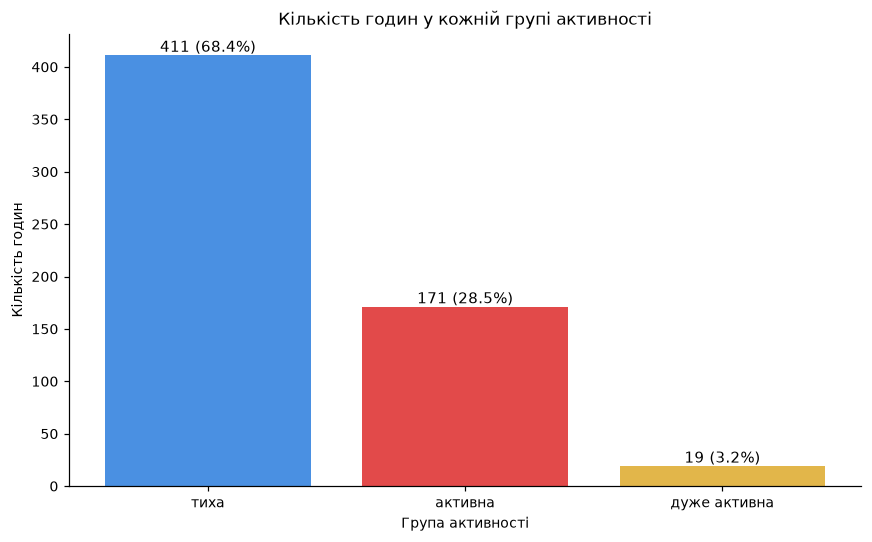

In [30]:
order = ['тиха', 'активна', 'дуже активна']
group_counts = M['група'].value_counts().reindex(order)
total_hours = len(M)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(group_counts.index, group_counts.values,
              color=['#4a90e2', '#e24a4a', '#e2b64a'])

ax.set_title('Кількість годин у кожній групі активності')
ax.set_xlabel('Група активності')
ax.set_ylabel('Кількість годин')

for bar in bars:
    height = bar.get_height()
    percentage = (height / total_hours) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, height,
            f'{int(height)} ({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**Висновок:** Переважна більшість годин (68.4%) у періоді спостережень належить до "тихої" групи. "Активні" години становлять близько 28.5%, а "дуже активні" - лише 3.2%. Це свідчить про те, що сильні геомагнітні збурення є рідкісними подіями, і більшу частину часу космічна погода залишається відносно спокійною.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

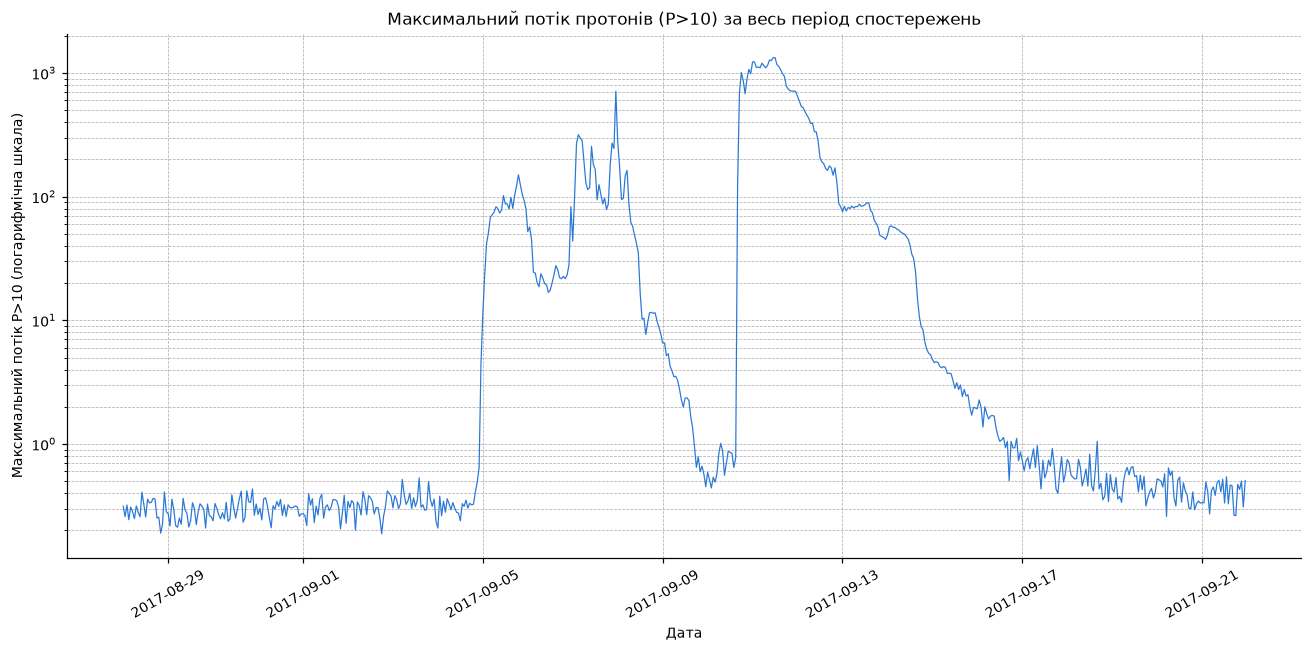

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))

# Побудова графіка з логарифмічною шкалою
ax.plot(M['ts'], M['P>10_max'], color='#2a78d6', linewidth=0.8)

# Налаштування логарифмічної шкали по осі Y
ax.set_yscale('log')

ax.set_title('Максимальний потік протонів (P>10) за весь період спостережень')
ax.set_xlabel('Дата')
ax.set_ylabel('Максимальний потік P>10 (логарифмічна шкала)')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, which="both", ls="--", linewidth=0.5)

plt.tight_layout()
plt.show()

**Висновок:** На графіку видно, що майже весь час потік протонів (P>10) був дуже низьким - близько 0.1-1. Але на цьому спокійному тлі сталося два різкі сплески: перший - приблизно 5-7 вересня, другий і значно потужніший - 10-12 вересня, коли потік підскочив приблизно у 100 000 разів. Після другого піку потік поступово знизився й до 20 вересня повернувся до звичайного рівня. Така картина типова для космічної погоди: більшість часу все спокійно, але іноді стаються короткі, але дуже сильні спалахи, які й визначають усю активність періоду.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

In [32]:
print(M.columns.tolist())

['ts', 'P>1_mean', 'P>1_max', 'P>5_mean', 'P>5_max', 'P>10_mean', 'P>10_max', 'P>30_mean', 'P>30_max', 'P>50_mean', 'P>50_max', 'P>100_mean', 'P>100_max', 'E>0.8_mean', 'E>0.8_max', 'E>2.0_mean', 'E>2.0_max', 'speed', 'density', 'F10.7', 'група']


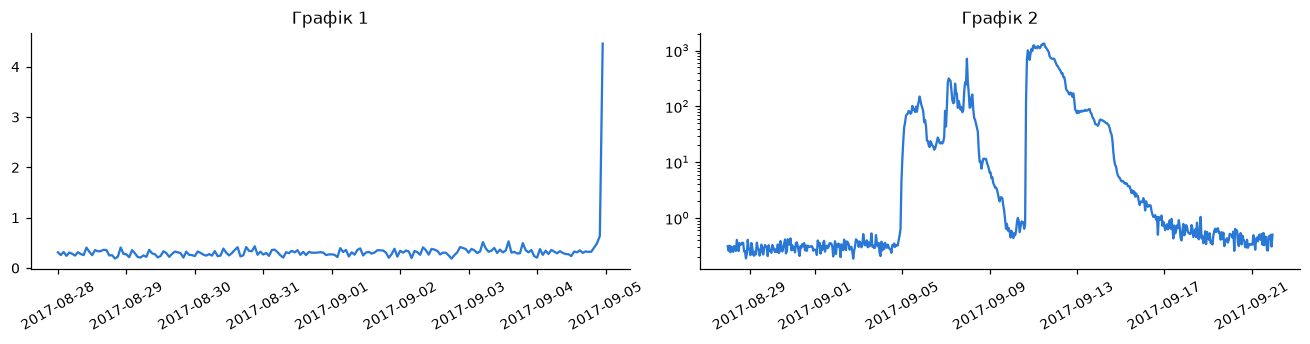

In [33]:
СТОВПЕЦЬ = 'P>10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: Людина, яка бачила лише перший графік, подумала б, що космічна погода в цей період була спокійною і стабільною. Потік протонів весь час тримався на дуже низькому рівні (близько 0.5), без жодних коливань - і лише в самий останній момент різко підскочив угору. Це виглядає як несподівана випадкова подія в кінці тижня.

2. Висновок з другого графіка: Людина, яка бачила лише другий графік, зробила б висновок, що в цей період сталася потужна і тривала космічна подія: спочатку спокійний фон, потім різкий сплеск 5-7 вересня, спад і ще потужніший пік 10-12 вересня, після чого потік поступово згасав аж до 20 вересня. Тобто картина активності - це ціла подія, а не поодинокий випадок.

3. Дві відмінності між ними: Між двома графіками є дві принципові відмінності, обидві закладені в коді, а не в даних. По-перше, вони охоплюють різні часові проміжки: перший графік показує лише перший тиждень спостережень (з 28 серпня по 5 вересня), тоді як другий охоплює весь період (до 21 вересня). Через це на першому графіку ми бачимо тільки початок подій і один різкий стрибок у самому кінці, а на другому — всю картину активності повністю, включно з другим, найпотужнішим піком 10–12 вересня. По-друге, вони використовують різні шкали по осі Y: перший — звичайну лінійну, другий — логарифмічну. Це критично важливо, бо значення потоку змінюються в сотні тисяч разів: на лінійній шкалі низький фоновий рівень (близько 0.5) і пік (десятки тисяч) неможливо побачити одночасно — фон виглядає як пласка лінія, а сам сплеск просто «вилітає» вгору. Логарифмічна шкала стискає діапазон так, що видно і дрібні коливання, і великі піки одночасно, тому на другому графіку чітко проглядаються обидва сплески та поступове згасання між ними.


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

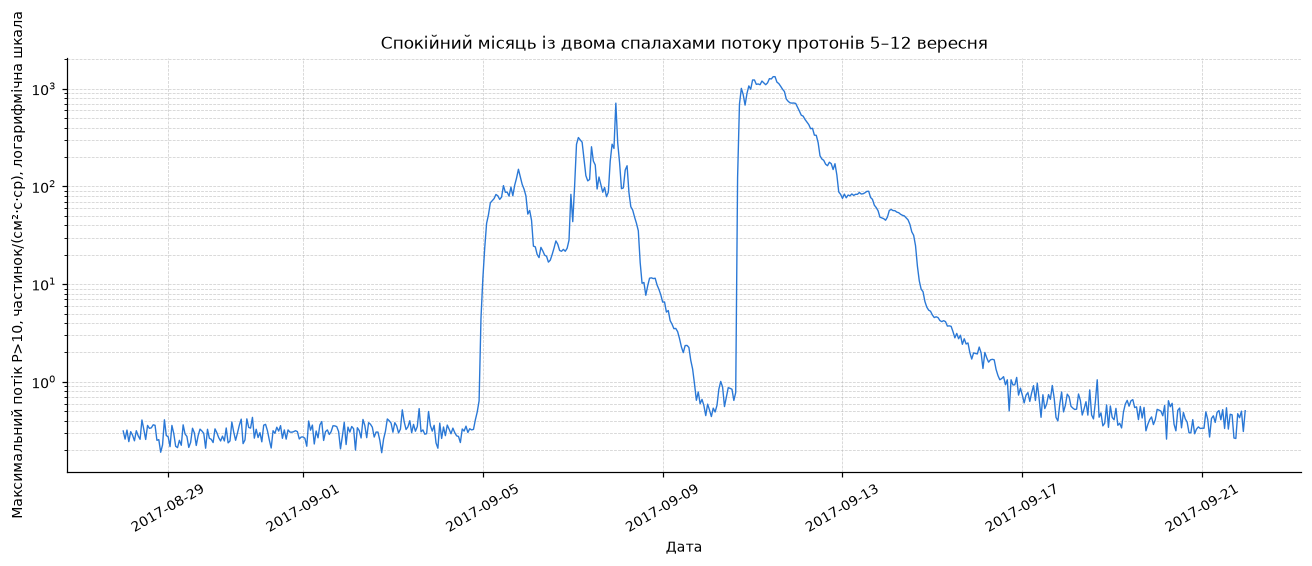

In [34]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(M['ts'], M['P>10_max'], color='#2a78d6', linewidth=0.9)
ax.set_yscale('log')

ax.set_title('Спокійний місяць із двома спалахами потоку протонів 5–12 вересня')
ax.set_xlabel('Дата')
ax.set_ylabel('Максимальний потік P>10, частинок/(см²·с·ср), логарифмічна шкала')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, which='both', ls='--', linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()

**Відповідь 6.2:** *(чому ви побудували графік саме так)*
Я обрала саме такий вигляд графіка з двох причин. По-перше, я взяла увесь часовий проміжок (а не один тиждень, як на графіку 1 із завдання 6.1), бо завдання вимагає чесно показати, що відбувалося за весь період - а головна подія (найпотужніший пік) припадає саме на середину вересня, тож обрізати дані не можна. По-друге, я використала логарифмічну шкалу по осі Y, бо значення потоку змінюються в сотні тисяч разів: фонові години мають близько 0.5, а піки сягають десятків тисяч. На звичайній лінійній шкалі ці два масштаби неможливо побачити одночасно - низький фон перетворився б на пласку лінію, а самі піки виглядали б як окремі вертикальні стрибки без форми. Логарифмічна шкала стискає діапазон так, що видно і фон, і обидва піки, і поступове згасання між ними. Заголовок я сформулювала як готовий висновок, щоб читач зрозумів головне ще до того, як роздивиться криву.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** Переважна більшість спостережуваних годин (68.4%) належить до "тихої" групи, а "дуже активні" години становлять лише 3.2%. Це видно на графіку 4 етапу 5, де стовпчик "тихої" групи значно перевищує інші. Отже, сильні геомагнітні збурення - рідкісні події, і більшу частину часу космічна погода залишається спокійною.

**Спостереження 2:** Потік P>5 має дуже нерівний розподіл: медіана становить всього 0.60, а середнє - 156.59, тобто різниця у 260 разів. Це видно на гістограмі в розділі "Графік 1": майже всі години згруповані біля нуля, але кілька поодиноких годин зі спалахами сильно зміщують середнє вгору. Отже, середнє тут не описує типову годину і його не можна використовувати без медіани.

**Спостереження 3:** Потік протонів P>10 у часі поводиться нерівномірно: після тривалого спокійного періоду (28 серпня - 4 вересня) відбулися два різкі спалахи - 5-7 вересня і потужніший 10-12 вересня, де значення зросли у сотні тисяч разів порівняно з фоном. Це видно на графіку 5 етапу 5 (з логарифмічною шкалою): низький фон і два чіткі піки. Отже, вся активність досліджуваного періоду зосереджена в кількох днях, а решта часу - спокійний фон.


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [35]:
rows_with_nan = M.isnull().any(axis=1)

num_rows_with_nan = rows_with_nan.sum()
total_rows = len(M)

fraction_with_nan = (num_rows_with_nan / total_rows) * 100

print(f"Рядків із хоча б одним пропуском: {num_rows_with_nan} з {total_rows}")
print(f"Частка рядків із пропусками: {fraction_with_nan:.2f}%")

print("\nПропуски по стовпцях:")
print(M.isnull().sum()[M.isnull().sum() > 0])

Рядків із хоча б одним пропуском: 9 з 601
Частка рядків із пропусками: 1.50%

Пропуски по стовпцях:
P>1_mean      1
P>1_max       1
P>5_mean      1
P>5_max       1
P>10_mean     1
P>10_max      1
P>30_mean     1
P>30_max      1
P>50_mean     1
P>50_max      1
P>100_mean    1
P>100_max     1
E>0.8_mean    1
E>0.8_max     1
E>2.0_mean    1
E>2.0_max     1
speed         8
density       8
F10.7         1
dtype: int64


**Відповідь 7.2:** Розрахунок показує, що 9 рядків із 601 (1.5%) мають пропуск хоча б в одному стовпці. Причини дві. У 8 рядках порожні speed і density - це проміжок 4 вересня з 07:00 до 14:00, де у файлі стояв код -1, який на етапі 3.2 замінили на NaN. Ще в 1 рядку порожні всі потоки частинок і F10.7 - це година, у якій прилад не передав жодного вимірювання. Решта рядків заповнені повністю. Отже, пропусків у таблиці мало - всього 1.5%, і кожен має конкретну причину.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [36]:
ІНСТРУМЕНТИ_ШІ = 'DeepSeek'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'ні',
    'етап 3, паспорт даних і дивні значення':     'синтаксис',
    'етап 4, об’єднання таблиць':                 'синтаксис',
    'етап 5, побудова графіків':                  'синтаксис',
    'етап 5, формулювання висновків':             'текст, перероблено',
    'етапи 6–7, порівняння графіків і спостереження': 'текст, перероблено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = 'Виправила надто довгі висновки, переписавши їх своїми словами і скоротивши, лишаючи лише головне. Виправила деякі неправильно зчитані числові значення та назви колонок.'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [37]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Осінна Єлизавета Сергіївна
інструменти:                                   DeepSeek
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    ні
етап 3, паспорт даних і дивні значення:        синтаксис
етап 4, об’єднання таблиць:                    синтаксис
етап 5, побудова графіків:                     синтаксис
етап 5, формулювання висновків:                текст, перероблено
етапи 6–7, порівняння графіків і спостереження: текст, перероблено
------------------------------------------------------------------------------
перевірено автором:
Виправила надто довгі висновки, переписавши їх своїми словами і скоротивши, лишаючи лише головне. Виправила деякі неправильно зчитані числові значення та назви колонок.
Автор підтверджує, що може пояснити кожен рядок коду під час захисту.


---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [38]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (601, 21)


In [39]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
